<h1 style="font-size:300%"> LOAN DEFAULT MODEL. </h1>

<h1> Dataset Description </h1>
This model predicts whether a person will default on their loan. The dataset contains information about loan applicants, including personal attributes such as age, income, and employment length, as well as loan-specific details such as loan amount, interest rate, and loan grade.


<h1>Domain Understanding </h1>
Before letting a machine predict default risk, it is important to understand what factors banks consider when approving loans. From a bank's perspective, approving a loan for someone who defaults is more costly than rejecting a creditworthy applicant - since borrowers may have no assets or declare bankruptcy. This model is intended as a decision-support tool and should not be the sole factor in loan approval decisions. This will be further discussed in the domain analysis report.

<h1> Analytical Approach </h1>
This is a binary classification problem. The target variable is loan_status. The dataset contains a mix of numerical and categorical features, which will require appropriate preprocessing steps such as encoding categorical variables and scaling numerical features. The model will be evaluated using metrics such as accuracy, precision, recall, and the F1 score to ensure it effectively identifies potential defaulters.

Importation of libraries.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

<h2>Loading the dataset</h2>


A random sample of 10 records for a quick visual inspection of the raw data - checking for anomalies such as missing values, duplicates, or implausible entries (e.g. unusually high age values).

In [54]:
df = pd.read_csv('C:/Users/AK/source/repos/Loan-model/credit_risk_dataset.csv')

df.sample(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
31315,39,85000,RENT,4.00,HOMEIMPROVEMENT,A,12000,6.03,0,0.14,N,12
11593,22,70000,RENT,5.00,PERSONAL,A,10000,6.03,0,0.14,N,3
30470,37,29000,RENT,5.00,PERSONAL,E,7200,19.03,1,0.25,Y,14
20908,27,38004,MORTGAGE,0.00,DEBTCONSOLIDATION,D,12000,16.77,1,0.32,N,6
19867,33,51000,RENT,0.00,VENTURE,A,11000,9.63,0,0.22,N,7
29011,28,42000,MORTGAGE,4.00,HOMEIMPROVEMENT,B,10000,10.75,0,0.24,N,6
9,21,10000,OWN,6.00,VENTURE,D,1600,14.74,1,0.16,N,3
26635,27,109000,MORTGAGE,7.00,EDUCATION,A,3950,6.03,0,0.04,N,7
8753,23,60000,MORTGAGE,6.00,EDUCATION,A,1200,6.03,0,0.02,N,3
29540,36,13440,RENT,2.00,EDUCATION,D,2400,17.49,1,0.18,Y,11


In [55]:
print (f"number of rows: {df.shape[0]}, number of columns: {df.shape[1]}")

number of rows: 32581, number of columns: 12


In [56]:
df.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

Understanding the data types of 

In [57]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

## Initial Data Inspection

The dataset contains **32,581 rows and 12 columns**. Below we inspect the data types of each column and check for missing values.

Columns are a mix of numerical (`int64`, `float64`) and categorical (`object`) types. Two columns contain missing values: `loan_int_rate` (3,116 missing) and `person_emp_length` (895 missing). These will need to be addressed during the data cleaning phase. our target variable: `loan_status`.

## Data Dictionary

| Feature | Type | Description |
|---|---|---|
| `person_age` | int | Age of the applicant |
| `person_income` | int | Annual income |
| `person_home_ownership` | categorical | Home ownership status (RENT, OWN, MORTGAGE) |
| `person_emp_length` | float | Employment length in years |
| `loan_intent` | categorical | Purpose of the loan |
| `loan_grade` | categorical | Loan grade assigned by the lender |
| `loan_amnt` | int | Loan amount requested |
| `loan_int_rate` | float | Interest rate on the loan |
| `loan_status` | int | Target variable - 0 = no default, 1 = default |
| `loan_percent_income` | float | Loan amount as a percentage of income |
| `cb_person_default_on_file` | categorical | Whether applicant has a historical default (Y/N) |
| `cb_person_cred_hist_length` | int | Length of credit history in years |

## Descriptive Statistics

`df.describe()` provides a statistical summary of all numerical columns including count, 
mean, standard deviation, and min/max values. This helps identify the range and spread 
of each feature and flag potential outliers.

## Outlier Detection

Two columns contain clearly implausible values:

- `person_age` — maximum value is 144, which is biologically impossible. 
  Investigation shows 5 rows exceed age 100.
- `person_emp_length` — maximum value is 123 years, which is impossible. 
  **2 rows** exceed 60 years of employment.

These rows are likely data errors and will be removed during the cleaning phase.

In [58]:
pd.options.display.float_format = '{:,.2f}'.format
df.describe()


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,"32,581.00","32,581.00","31,686.00","32,581.00","29,465.00","32,581.00","32,581.00","32,581.00"
mean,27.73,"66,074.85",4.79,"9,589.37",11.01,0.22,0.17,5.80
std,6.35,"61,983.12",4.14,"6,322.09",3.24,0.41,0.11,4.06
min,20.00,"4,000.00",0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,"38,500.00",2.00,"5,000.00",7.90,0.00,0.09,3.00
50%,26.00,"55,000.00",4.00,"8,000.00",10.99,0.00,0.15,4.00
75%,30.00,"79,200.00",7.00,"12,200.00",13.47,0.00,0.23,8.00
max,144.00,"6,000,000.00",123.00,"35,000.00",23.22,1.00,0.83,30.00


In [59]:
print(df[df['person_age'] > 100].shape[0])
print(df[df['person_emp_length'] > 60].shape[0])

5
2


## Class Distribution

The target variable `loan_status` is imbalanced: 78% of applicants did not default (0) 
and 22% did (1). This means accuracy alone is a misleading evaluation metric - a model 
that predicts "no default" for every applicant would achieve 78% accuracy.

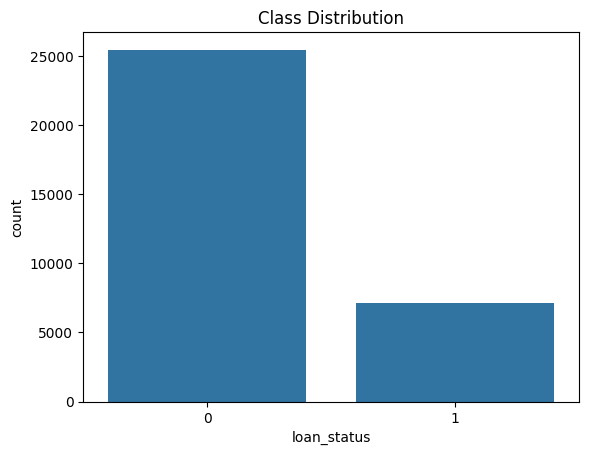

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [60]:
sns.countplot(x='loan_status', data=df)
plt.title('Class Distribution')
plt.show()

df['loan_status'].value_counts()

## Numerical Feature Distributions & Outlier Detection

Histograms and boxplots were generated for all numerical features to understand 
their distributions and identify outliers. Three columns show problematic values:

- `person_age` - most applicants are between 20-40. 
  Values above 100 (max 144) are biologically impossible and are data errors.
- `person_income` - a maximum of $6,000,000 while 75% 
  of applicants earn under $79,200. This extreme value distorts the distribution 
  but may represent a real person.
- `person_emp_length` - max value of 123 years is impossible.

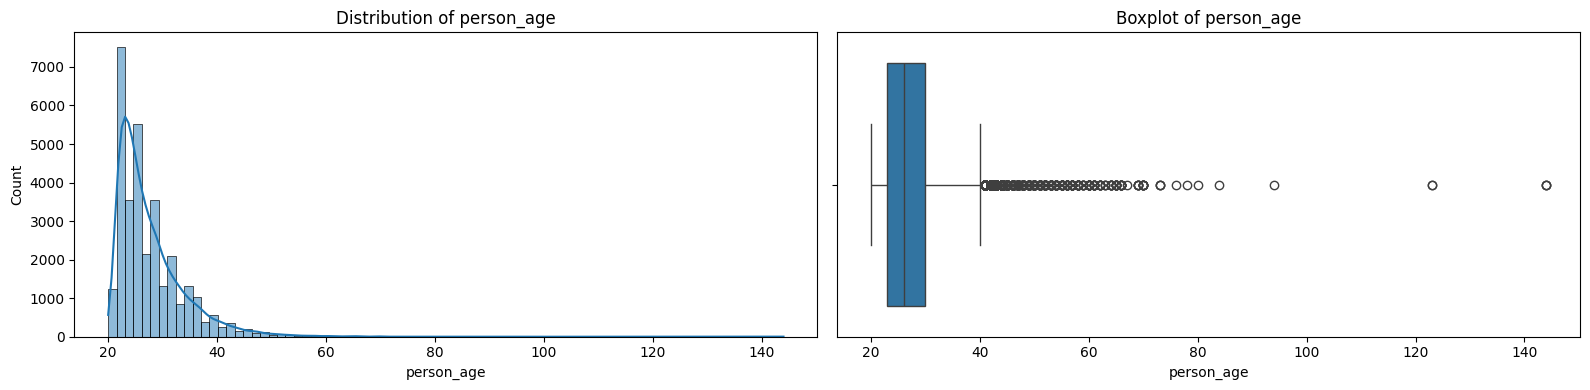

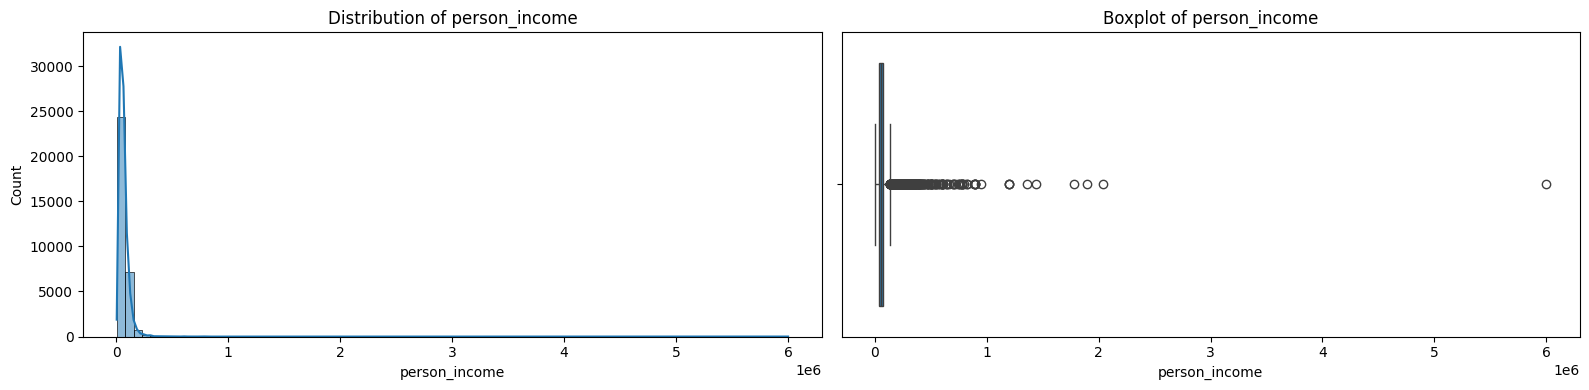

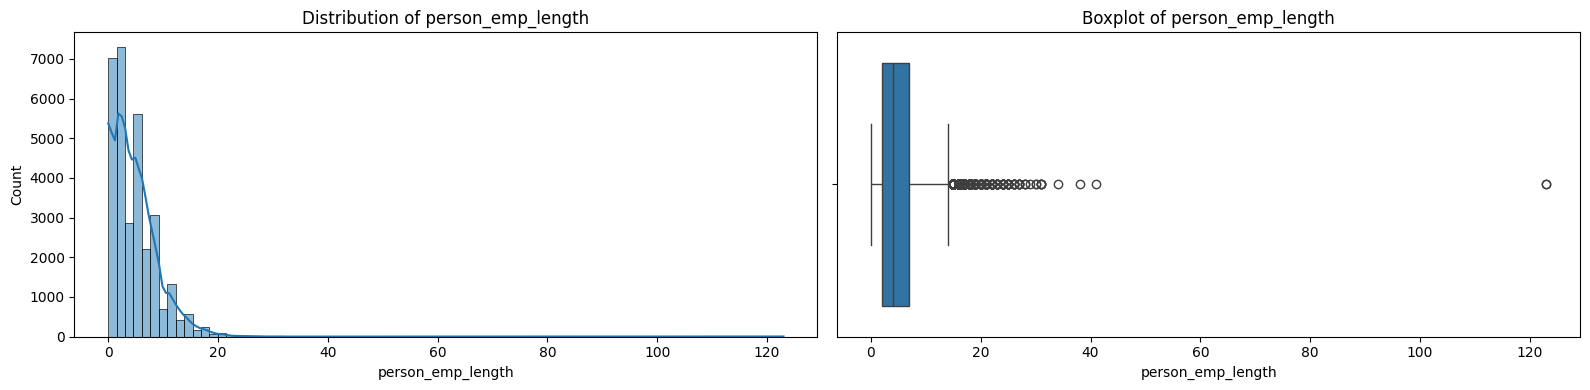

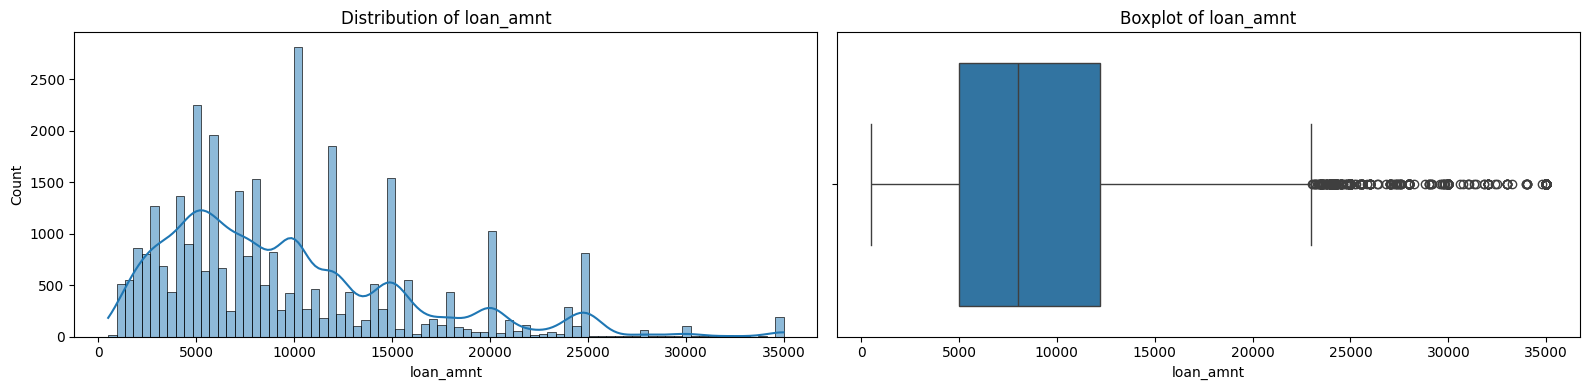

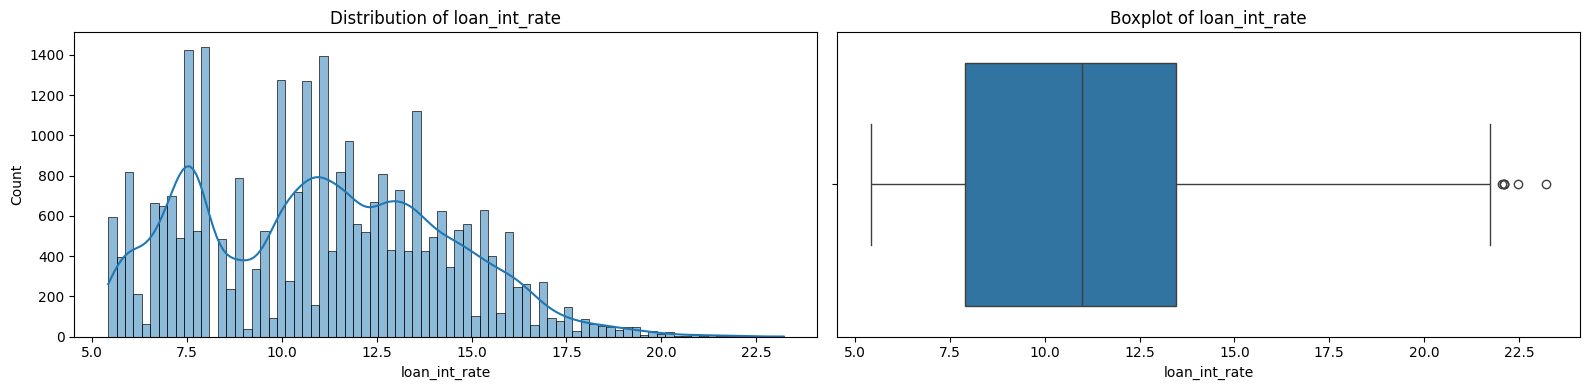

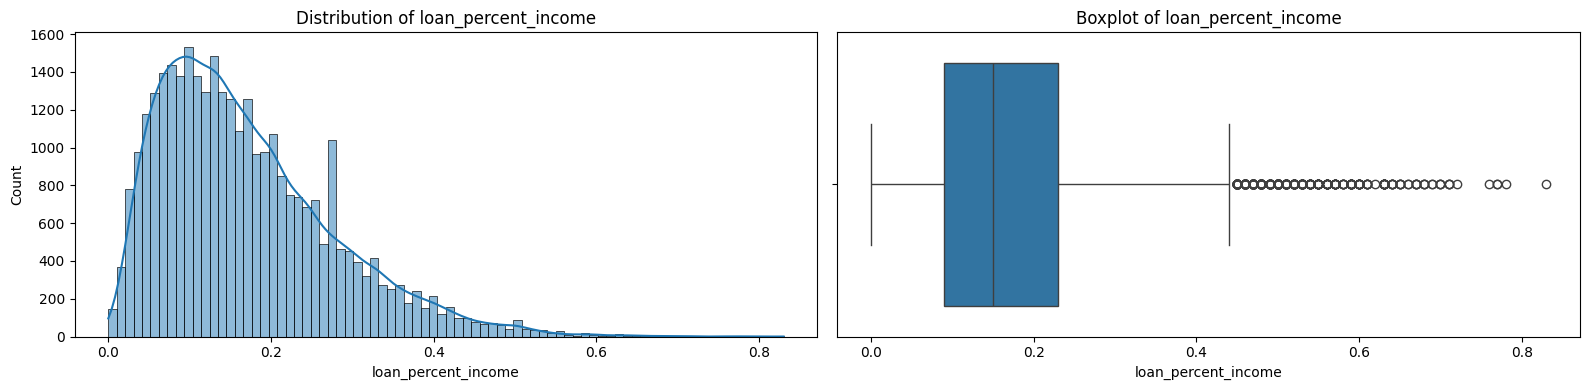

In [61]:
numerical_cols = ['person_age', 'person_income', 'person_emp_length', 
                  'loan_amnt', 'loan_int_rate', 'loan_percent_income']
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    
    sns.histplot(data=df, x=col, kde=True, bins=80, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    
    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()
# df[numerical_cols].hist(bins=30, figsize=(12,8))
# plt.tight_layout()
# plt.show()


## Categorical Feature Distributions

Bar charts were generated for all categorical features. Key observations:

- `person_home_ownership` is dominated by RENT and MORTGAGE categories.
- `loan_intent` is fairly evenly spread across categories with EDUCATION and 
  MEDICAL being most common.



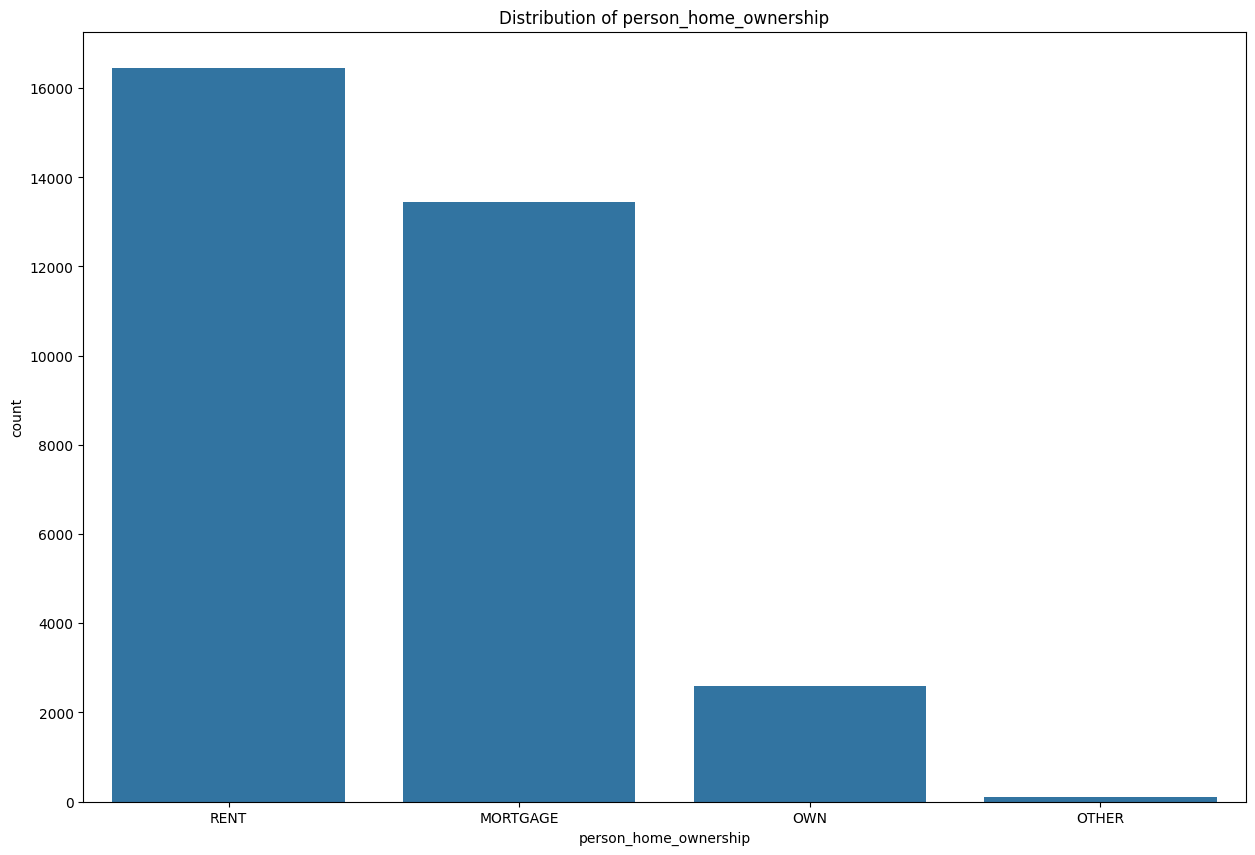

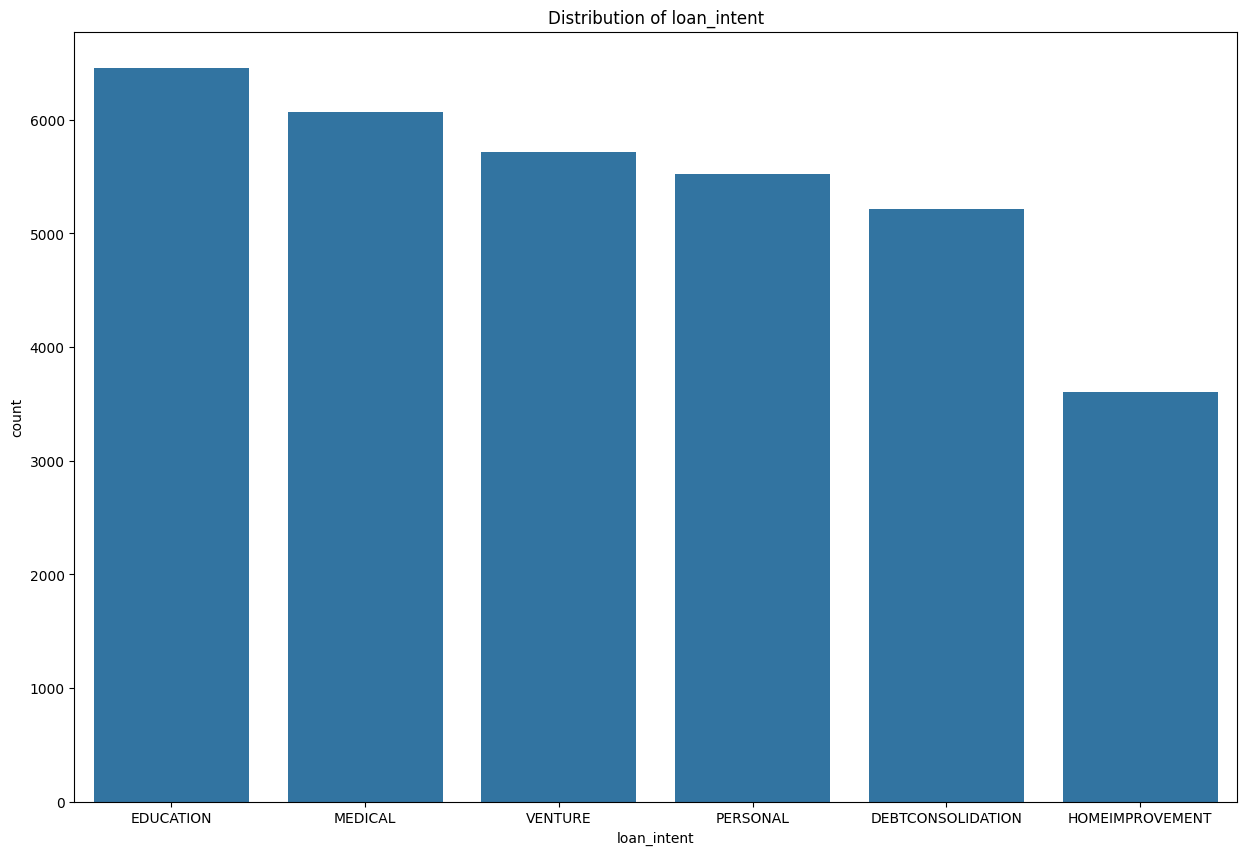

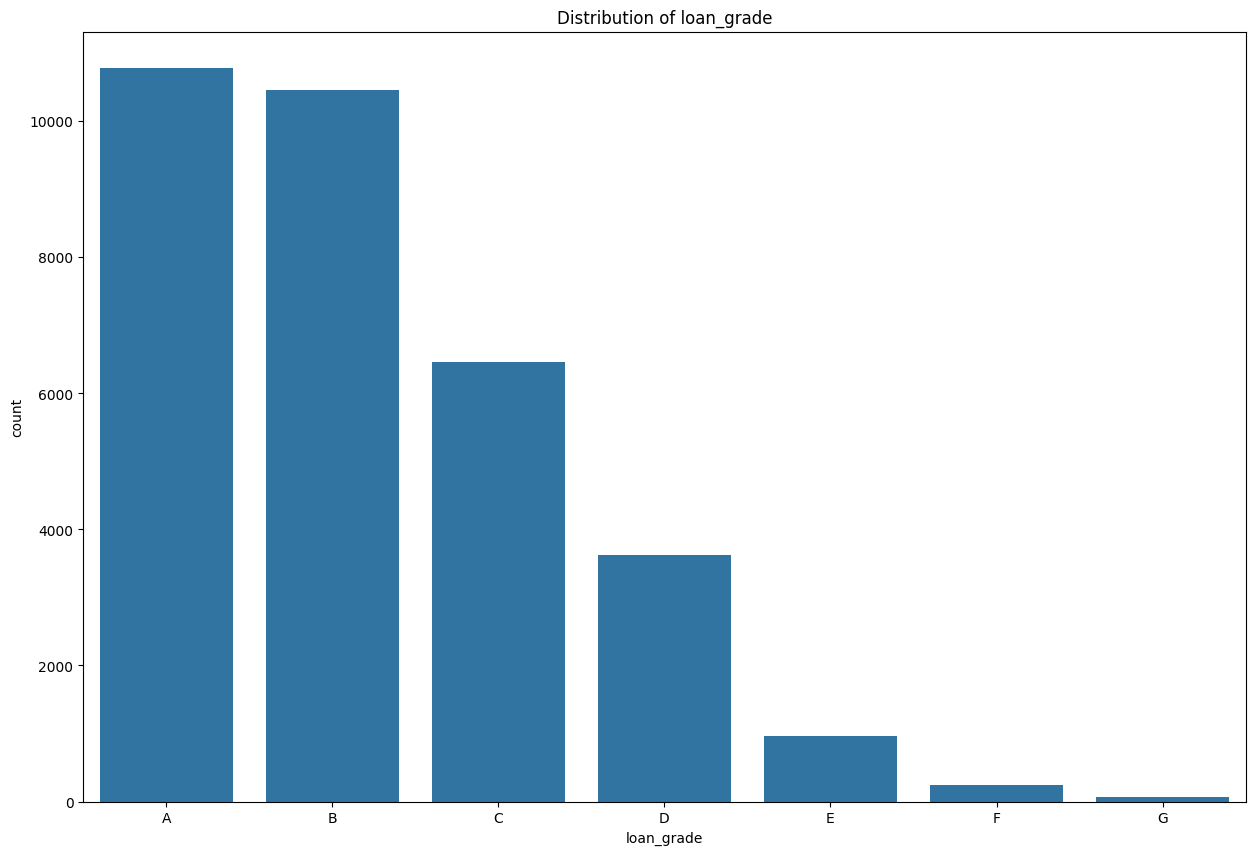

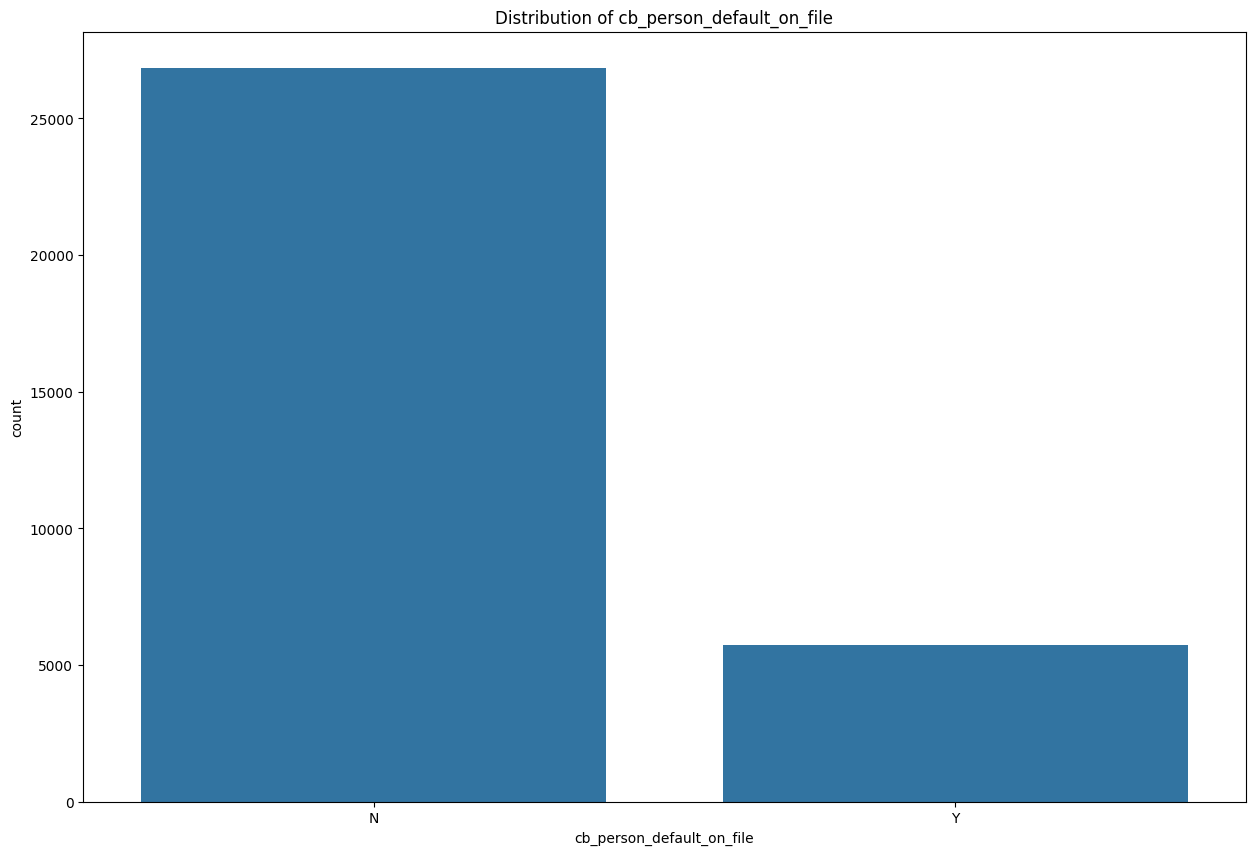

In [62]:
categorical_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in categorical_cols:
    plt.figure(figsize=(15, 10))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()


## Ratio Analysis: Default Rate by Loan Category

**Loan grade** shows the strongest pattern - Grade G has the highest default 
rate (90%) while Grade A sits at 10%, making it a likely strong predictor and a possible feature to use during the pipeline build

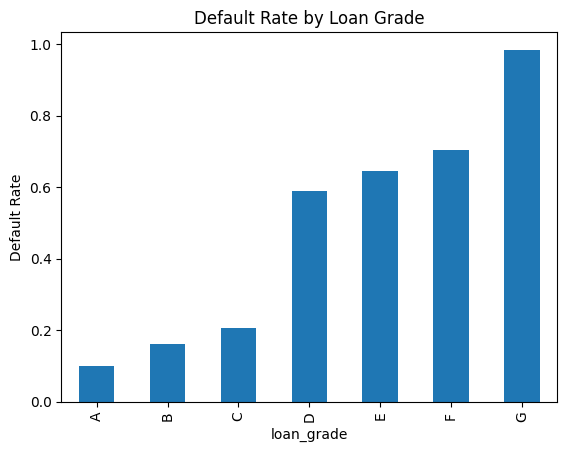

In [63]:
df.groupby('loan_grade')['loan_status'].mean().sort_index().plot(kind='bar')
plt.title('Default Rate by Loan Grade')
plt.ylabel('Default Rate')
plt.show()

## Correlation Heatmap

The heatmap reveals which numerical features correlate most strongly with `loan_status`:

- `loan_int_rate` (0.34) and `loan_percent_income` (0.38) have the strongest correlation with our target variable  `loan_status`
- `person_income` (-0.14) shows a negative correlation - higher income applicants 
  are less likely to default.
- `person_age` and `cb_person_cred_hist_length` have a very high correlation (0.86) 
  with each other, meaning they carry largely the same information. 

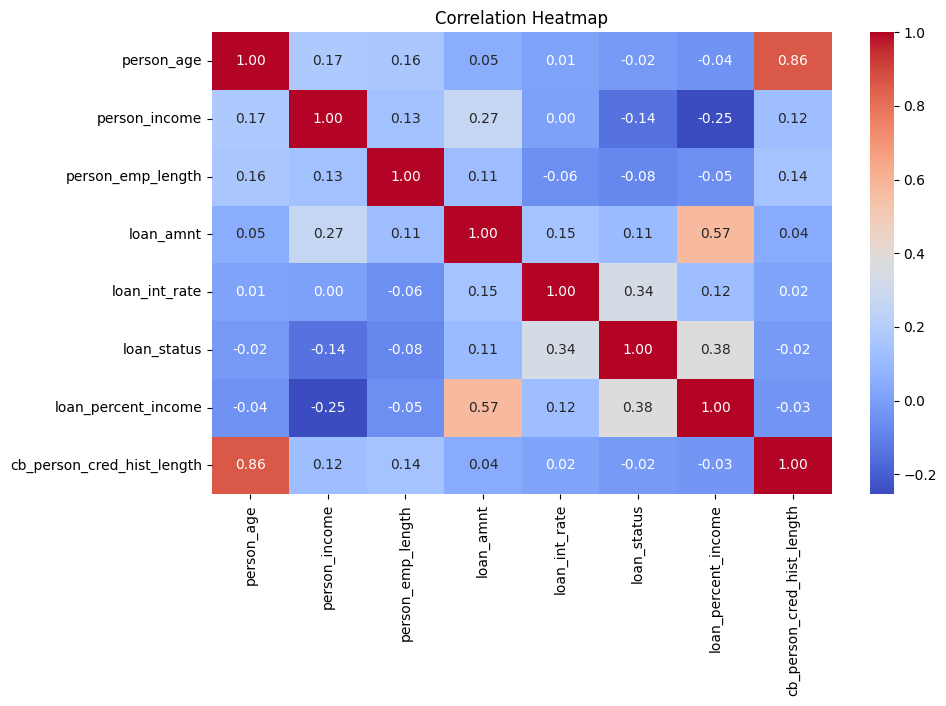

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Data Cleaning

Based on the EDA, three issues were identified and addressed:

1. Rows with impossible values were removed - `person_age` above 100 and 
   `person_emp_length` above 60 are biologically impossible and treated as 
   data entry errors.
2. Missing values in `loan_int_rate` and `person_emp_length` were filled 
   using the column median rather than the mean, since both distributions 
   are skewed, extreme values would pull the mean upward.

In [65]:
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print(df.isnull().sum())
print(f"\nRows remaining: {len(df)}")

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Rows remaining: 31679


157 duplicate rows were removed to prevent the model from training 
on the same data multiple times.

In [68]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Rows remaining after removing duplicates: {len(df)}")

Duplicate rows: 0
Rows remaining after removing duplicates: 31522
